# Setup

## Connect or build the database

In [1]:
import duckdb
import time
from pathlib import Path

DB_PATH = "./mimiciv.duckdb"
MIMIC_PATH = Path("../mimic/physionet.org/files/mimiciv/3.1")

HOSP = MIMIC_PATH / "hosp"
ICU = MIMIC_PATH / "icu"

# Only the tables we actually use in this project
TABLES = {
    # Hosp module: demographics, admissions, and labs
    "hosp.patients": HOSP / "patients.csv.gz",
    "hosp.admissions": HOSP / "admissions.csv.gz",
    "hosp.labevents": HOSP / "labevents.csv.gz",
    "hosp.d_labitems": HOSP / "d_labitems.csv.gz",
    # ICU module: stays, charted vitals, and IV medications
    "icu.icustays": ICU / "icustays.csv.gz",
    "icu.chartevents": ICU / "chartevents.csv.gz",
    "icu.d_items": ICU / "d_items.csv.gz",
    "icu.inputevents": ICU / "inputevents.csv.gz",
}


def load_tables(con):
    con.execute("CREATE SCHEMA IF NOT EXISTS hosp")
    con.execute("CREATE SCHEMA IF NOT EXISTS icu")
    for table_name, file_path in TABLES.items():
        if not file_path.exists():
            print(f"  SKIP {table_name}: file not found at {file_path}")
            continue
        print(f"  Loading {table_name}...", end=" ", flush=True)
        start = time.time()
        con.execute(f"DROP TABLE IF EXISTS {table_name}")
        con.execute(f"""
            CREATE TABLE {table_name} AS
            SELECT * FROM read_csv_auto('{file_path}', header=True)
        """)
        n_rows = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
        elapsed = time.time() - start
        print(f"{n_rows:,} rows in {elapsed:.1f}s")


def create_views(con):
    # Joins patients with admissions; adds hospital LOS in hours
    con.execute("""
        CREATE OR REPLACE VIEW patient_admissions AS
        SELECT
            p.subject_id, p.gender, p.anchor_age, p.anchor_year, p.dod,
            a.hadm_id, a.admittime, a.dischtime, a.deathtime,
            a.admission_type, a.admission_location, a.discharge_location,
            a.insurance, a.language, a.marital_status, a.race,
            a.hospital_expire_flag,
            EXTRACT(EPOCH FROM (a.dischtime - a.admittime)) / 3600 AS hospital_los_hours
        FROM hosp.patients p
        JOIN hosp.admissions a ON p.subject_id = a.subject_id
    """)

    # Enriches ICU stays with demographics from patient_admissions; adds ICU LOS in hours
    con.execute("""
        CREATE OR REPLACE VIEW icu_stays_full AS
        SELECT
            i.stay_id, i.subject_id, i.hadm_id,
            i.first_careunit, i.last_careunit, i.intime, i.outtime,
            EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 AS icu_los_hours,
            pa.gender, pa.anchor_age, pa.race, pa.insurance,
            pa.admission_type, pa.hospital_expire_flag, pa.dod
        FROM icu.icustays i
        JOIN patient_admissions pa ON i.hadm_id = pa.hadm_id
    """)

    # Filters chartevents to CAM/delirium assessments only; normalises values to binary 0/1
    con.execute("""
        CREATE OR REPLACE VIEW cam_icu_assessments AS
        SELECT
            ce.subject_id, ce.hadm_id, ce.stay_id, ce.charttime, ce.itemid,
            di.label AS item_label, ce.value, ce.valuenum,
            CASE 
                WHEN ce.value IN ('Positive', 'Yes', 'positive', 'yes') THEN 1
                WHEN ce.value IN ('Negative', 'No', 'negative', 'no') THEN 0
                ELSE NULL
            END AS cam_positive
        FROM icu.chartevents ce
        JOIN icu.d_items di ON ce.itemid = di.itemid
        WHERE LOWER(di.label) LIKE '%cam%'
           OR LOWER(di.label) LIKE '%delirium%'
           OR LOWER(di.label) LIKE '%confusion assessment%'
    """)

    # Aggregates CAM assessments per ICU stay: total/positive counts, ever-delirious flag, first/last assessment times
    con.execute("""
        CREATE OR REPLACE VIEW delirium_summary AS
        SELECT
            stay_id,
            COUNT(*) AS total_assessments,
            SUM(cam_positive) AS positive_assessments,
            MAX(cam_positive) AS ever_delirious,
            MIN(CASE WHEN cam_positive = 1 THEN charttime END) AS first_positive_time,
            MIN(charttime) AS first_assessment_time,
            MAX(charttime) AS last_assessment_time
        FROM cam_icu_assessments
        WHERE cam_positive IS NOT NULL
        GROUP BY stay_id
    """)

    # Joins lab results with item labels and categories for human-readable lab names and units
    con.execute("""
        CREATE OR REPLACE VIEW labs_labeled AS
        SELECT
            le.subject_id, le.hadm_id, le.charttime, le.itemid,
            dl.label AS lab_name, dl.category AS lab_category,
            le.value, le.valuenum, le.valueuom AS unit, le.flag
        FROM hosp.labevents le
        JOIN hosp.d_labitems dl ON le.itemid = dl.itemid
    """)


# Build only if the database doesn't exist; otherwise just connect
if Path(DB_PATH).exists():
    print(f"Database already exists at {DB_PATH}, connecting...")
    con = duckdb.connect(database=DB_PATH)
else:
    print(f"No database found at {DB_PATH}, building from raw files...")
    if not MIMIC_PATH.exists():
        raise FileNotFoundError(
            f"Raw MIMIC-IV files not found at {MIMIC_PATH}. "
            f"Update MIMIC_PATH at the top of this cell to point to your data."
        )
    con = duckdb.connect(database=DB_PATH)
    print("\n>>> Loading tables...")
    load_tables(con)
    print("\n>>> Creating views...")
    create_views(con)
    print(f"\nDatabase built at {DB_PATH}")

print("Connection ready.")

Database already exists at ./mimiciv.duckdb, connecting...
Connection ready.


## Helper for saving figures

In [2]:
import os
import matplotlib.pyplot as plt

os.makedirs("./figures", exist_ok=True)
os.makedirs("./data", exist_ok=True)


def save_fig(filename):
    """Save the current matplotlib figure to ./figures/ at 150 DPI."""
    path = f"./figures/{filename}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved {path}")

# Exploration

## MIMIC-IV table sizes

In [3]:
# Count rows in the core tables to get a sense of the dataset's scale
sizes = con.execute("""
    SELECT 'patients' AS table_name, COUNT(*) AS n_rows FROM hosp.patients
    UNION ALL
    SELECT 'admissions', COUNT(*) FROM hosp.admissions
    UNION ALL
    SELECT 'icu_stays', COUNT(*) FROM icu.icustays
    UNION ALL
    SELECT 'chartevents', COUNT(*) FROM icu.chartevents
    UNION ALL
    SELECT 'labevents', COUNT(*) FROM hosp.labevents
    UNION ALL
    SELECT 'inputevents', COUNT(*) FROM icu.inputevents
""").df()
print(sizes.to_string(index=False))

 table_name    n_rows
   patients    364627
 admissions    546028
  icu_stays     94458
chartevents 432997491
  labevents 158374764
inputevents  10953713


## Patient demographics

In [5]:
demo = con.execute("""
    SELECT subject_id, gender, anchor_age 
    FROM hosp.patients
""").df()

print(f"Patients: {len(demo):,}")
print("\nGender:")
print(demo["gender"].value_counts().to_string())
print("\nAge summary:")
print(demo["anchor_age"].describe().round(1).to_string())

Patients: 364,627

Gender:
gender
F    191984
M    172643

Age summary:
count    364627.0
mean         48.9
std          20.9
min          18.0
25%          29.0
50%          48.0
75%          65.0
max          91.0


## Age distribution plot

Saved ./figures/age_distribution.png


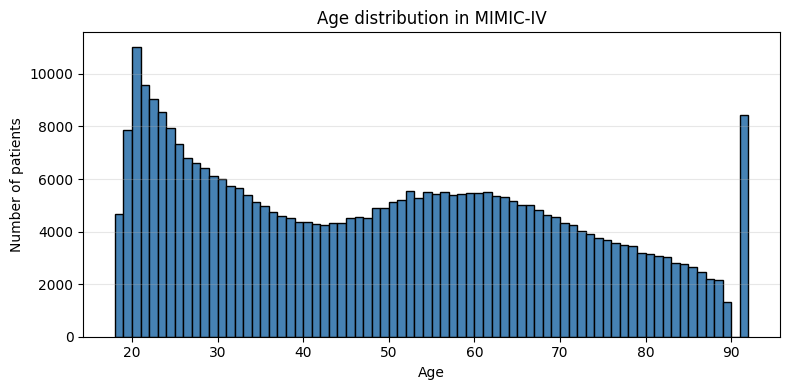

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
# One bin per integer age, range 18 to 91
ax.hist(demo["anchor_age"], bins=range(18, 93), color="steelblue", edgecolor="black")
ax.set_xlabel("Age")
ax.set_ylabel("Number of patients")
ax.set_title("Age distribution in MIMIC-IV")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig("age_distribution")
plt.show()

Anyone over 89 has their age set to a single value, 91, to prevent identification.

## ICU stays exploration

In [9]:
icu = con.execute("""
    SELECT 
        i.stay_id, i.subject_id, i.hadm_id,
        i.first_careunit, i.intime, i.outtime,
        EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 AS los_hours
    FROM icu.icustays i
""").df()

print(f"ICU stays: {len(icu):,}")
print(f"Unique patients with ICU stays: {icu['subject_id'].nunique():,}")
print("\nLength of stay (hours):")
print(icu["los_hours"].describe().round(1).to_string())

ICU stays: 94,458
Unique patients with ICU stays: 65,366

Length of stay (hours):
count    94444.0
mean        87.1
std        129.7
min          0.0
25%         26.3
50%         47.2
75%         92.7
max       5433.7


## ICU length of stay plot

Saved ./figures/icu_los_distribution.png


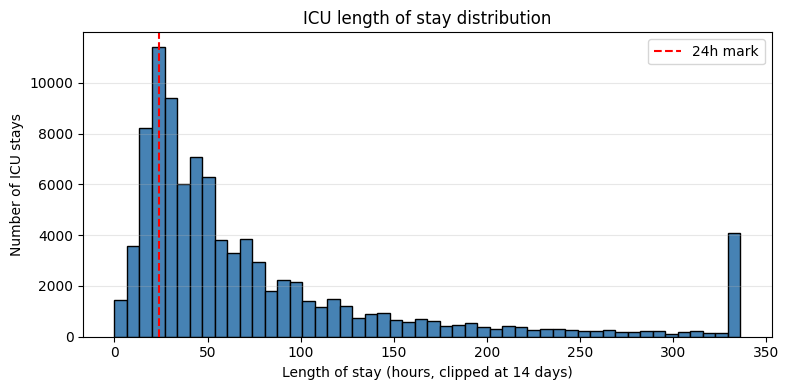


Fraction of ICU stays at least X hours long:
  >=    6h: 98.7%
  >=   12h: 95.8%
  >=   24h: 79.2%
  >=   48h: 49.1%
  >=   72h: 33.0%
  >=  168h: 11.8%


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
# Clip at 14 days for visibility; very long stays are rare and pull the axis
ax.hist(
    icu["los_hours"].clip(upper=14 * 24), bins=50, color="steelblue", edgecolor="black"
)
ax.axvline(24, color="red", linestyle="--", label="24h mark")
ax.set_xlabel("Length of stay (hours, clipped at 14 days)")
ax.set_ylabel("Number of ICU stays")
ax.set_title("ICU length of stay distribution")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig("icu_los_distribution")
plt.show()

# Also useful for the report: cumulative fraction by threshold
thresholds = [6, 12, 24, 48, 72, 168]
print("\nFraction of ICU stays at least X hours long:")
for t in thresholds:
    pct = (icu["los_hours"] >= t).mean()
    print(f"  >= {t:>4}h: {pct:.1%}")

## ICU care unit breakdown

In [11]:
careunits = icu["first_careunit"].value_counts()
print("ICU stays by care unit:")
print(careunits.to_string())

ICU stays by care unit:
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
PACU                                                  122
Intensive Care Unit (ICU)                              33
Medicine                                               16
Surgery/Trauma                                         10
Medicine/Cardiology Intermediate                        1
Med/Surg                                                1
Neurology                        

## CAM-ICU items in d_items

In [12]:
cam_items = con.execute("""
    SELECT itemid, label, category, param_type
    FROM icu.d_items
    WHERE LOWER(label) LIKE '%cam%'
       OR LOWER(label) LIKE '%delirium%'
       OR LOWER(label) LIKE '%confusion assessment%'
    ORDER BY label
""").df()
print(f"CAM/delirium related items: {len(cam_items)}")
print(cam_items.to_string(index=False))

CAM/delirium related items: 17
 itemid                             label                category param_type
 228334               CAM-ICU Altered LOC           Pain/Sedation       Text
 228303     CAM-ICU Disorganized thinking           Pain/Sedation       Text
 228335     CAM-ICU Disorganized thinking           Pain/Sedation       Text
 229324     CAM-ICU Disorganized thinking           Pain/Sedation       Text
 228301               CAM-ICU Inattention           Pain/Sedation       Text
 228336               CAM-ICU Inattention           Pain/Sedation       Text
 229325               CAM-ICU Inattention           Pain/Sedation       Text
 228337                 CAM-ICU MS Change           Pain/Sedation       Text
 229326                 CAM-ICU MS Change           Pain/Sedation       Text
 228300                 CAM-ICU MS change           Pain/Sedation       Text
 228302                  CAM-ICU RASS LOC           Pain/Sedation       Text
 229533                            Camino Acc

## Inspect actual values stored under CAM-ICU items

In [13]:
# Look at what values these CAM-ICU items actually take in chartevents
cam_values = con.execute("""
    SELECT 
        ce.itemid, 
        di.label,
        ce.value, 
        COUNT(*) AS n
    FROM icu.chartevents ce
    JOIN icu.d_items di ON ce.itemid = di.itemid
    WHERE di.itemid IN (228300, 228301, 228302, 228303, 228332, 228334, 228335, 
                        228336, 228337, 228688, 229324, 229325, 229326)
    GROUP BY ce.itemid, di.label, ce.value
    ORDER BY di.label, n DESC
""").df()
print(cam_values.to_string(index=False))

 itemid                         label                                          value      n
 228334           CAM-ICU Altered LOC                                            Yes 107833
 228334           CAM-ICU Altered LOC                                             No  21223
 228303 CAM-ICU Disorganized thinking                                             No  15064
 229324 CAM-ICU Disorganized thinking                                            Yes   9628
 229324 CAM-ICU Disorganized thinking                                             No   3454
 228335 CAM-ICU Disorganized thinking                                            Yes   2304
 228335 CAM-ICU Disorganized thinking                                             No   1155
 228335 CAM-ICU Disorganized thinking                               Unable to Assess    821
 228303 CAM-ICU Disorganized thinking                                            Yes    319
 229325           CAM-ICU Inattention                                           

Item 228332 "Delirium assessment" is the only item with clean "Positive" / "Negative" / "UTA" values and it's the overall CAM-ICU result, not a sub-component.

## Delirium assessment coverage in ICU stays

In [14]:
coverage = con.execute("""
    SELECT 
        COUNT(DISTINCT stay_id) AS stays_with_assessment,
        COUNT(*) AS total_assessments
    FROM icu.chartevents
    WHERE itemid = 228332
""").df()
print(coverage.to_string(index=False))

# How many ICU stays have NO delirium assessment at all?
no_assessment = con.execute("""
    SELECT COUNT(*) AS stays_without_assessment
    FROM icu.icustays
    WHERE stay_id NOT IN (
        SELECT DISTINCT stay_id 
        FROM icu.chartevents 
        WHERE itemid = 228332
    )
""").df()
print(no_assessment.to_string(index=False))

 stays_with_assessment  total_assessments
                 72944             610632
 stays_without_assessment
                    21514


Out of 94,458 ICU stays, 21,514 have no delirium assessment at all. If CAM-ICU was never done for those patients, we have no way to label them and they cannot be in our cohort.

## Delirium prevalence in assessable stays

In [15]:
# For each stay that has assessments, classify as: ever positive, only negative, or only UTA
prevalence = con.execute("""
    SELECT 
        stay_id,
        SUM(CASE WHEN value = 'Positive' THEN 1 ELSE 0 END) AS n_positive,
        SUM(CASE WHEN value = 'Negative' THEN 1 ELSE 0 END) AS n_negative,
        SUM(CASE WHEN value = 'UTA' THEN 1 ELSE 0 END) AS n_uta
    FROM icu.chartevents
    WHERE itemid = 228332
    GROUP BY stay_id
""").df()

print(f"Stays with at least one assessment: {len(prevalence):,}")


# Categorise each stay
def categorise(row):
    if row["n_positive"] > 0:
        return "ever_positive"
    if row["n_negative"] > 0:
        return "only_negative"
    return "only_uta"


prevalence["category"] = prevalence.apply(categorise, axis=1)

print("\nCategory breakdown:")
print(prevalence["category"].value_counts().to_string())
print("\nAs percentages:")
print(prevalence["category"].value_counts(normalize=True).round(3).to_string())

Stays with at least one assessment: 72,944

Category breakdown:
category
only_negative    47417
ever_positive    22462
only_uta          3065

As percentages:
category
only_negative    0.650
ever_positive    0.308
only_uta         0.042


The 3,065 UTA-only stays will need to be excluded later because we have no usable label for them.

After excluding UTA-only stays, the split is 22,462 positive vs 47,417 negative, which is 32% vs 68%, which is a moderate imbalance. This means we probably don't need SMOTE; class weighting alone should be enough.

## Timing of first positive delirium assessment

In [16]:
# For ever-positive stays, when does the first positive assessment occur (hours after ICU intime)?
timing = con.execute("""
    SELECT 
        ce.stay_id,
        i.intime,
        MIN(ce.charttime) AS first_positive,
        EXTRACT(EPOCH FROM (MIN(ce.charttime) - i.intime)) / 3600 AS hours_to_first_positive
    FROM icu.chartevents ce
    JOIN icu.icustays i ON ce.stay_id = i.stay_id
    WHERE ce.itemid = 228332 AND ce.value = 'Positive'
    GROUP BY ce.stay_id, i.intime
""").df()

print(f"Ever-positive stays: {len(timing):,}")
print("\nHours from ICU intime to first positive assessment:")
print(timing["hours_to_first_positive"].describe().round(1).to_string())

Ever-positive stays: 22,462

Hours from ICU intime to first positive assessment:
count    22462.0
mean        32.0
std         82.9
min      -8659.8
25%          2.4
50%         12.9
75%         38.1
max       1321.9


## Plot: distribution of time to first delirium

Saved ./figures/delirium_onset_timing.png


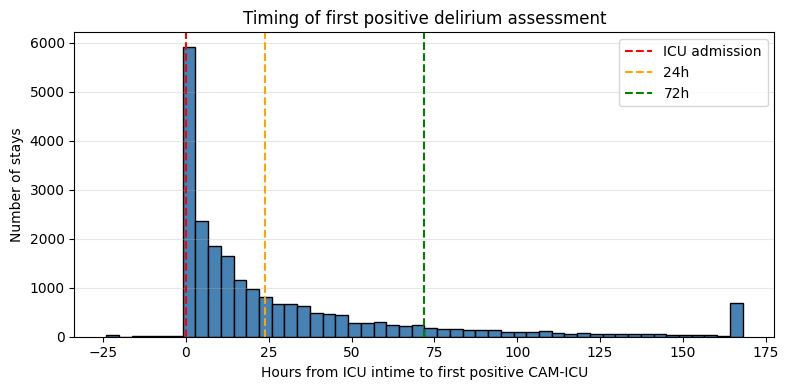


Fraction of first-positives within X hours of intime:
  <=    0h: 1.9%
  <=    6h: 35.3%
  <=   12h: 48.3%
  <=   24h: 64.2%
  <=   48h: 80.3%
  <=   72h: 87.7%
  <=  168h: 97.0%


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
# Clip at 7 days for visibility
ax.hist(
    timing["hours_to_first_positive"].clip(lower=-24, upper=168),
    bins=50,
    color="steelblue",
    edgecolor="black",
)
ax.axvline(0, color="red", linestyle="--", label="ICU admission")
ax.axvline(24, color="orange", linestyle="--", label="24h")
ax.axvline(72, color="green", linestyle="--", label="72h")
ax.set_xlabel("Hours from ICU intime to first positive CAM-ICU")
ax.set_ylabel("Number of stays")
ax.set_title("Timing of first positive delirium assessment")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig("delirium_onset_timing")
plt.show()

# What fraction of first-positives occur before various thresholds?
print("\nFraction of first-positives within X hours of intime:")
for t in [0, 6, 12, 24, 48, 72, 168]:
    pct = (timing["hours_to_first_positive"] <= t).mean()
    print(f"  <= {t:>4}h: {pct:.1%}")

## Quantify pre-ICU positive assessments

In [18]:
# How many ever-positive stays have their first positive BEFORE ICU intime?
before_icu = (timing["hours_to_first_positive"] < 0).sum()
print(
    f"Stays with first positive before ICU intime: {before_icu:,} ({before_icu/len(timing):.1%})"
)

# Look at how far before
pre_icu = timing[timing["hours_to_first_positive"] < 0]
print("\nDistribution of pre-ICU times (hours, negative = before intime):")
print(pre_icu["hours_to_first_positive"].describe().round(1).to_string())

Stays with first positive before ICU intime: 409 (1.8%)

Distribution of pre-ICU times (hours, negative = before intime):
count     409.0
mean      -31.6
std       431.4
min     -8659.8
25%        -0.6
50%        -0.2
75%        -0.1
max        -0.0


Only 409 stays have a positive assessment before ICU intime. For our cohort definition we'll exclude these 409 stays.

## Assessment frequency per stay

In [19]:
# How many delirium assessments per stay, and how spread out are they in time?
freq = con.execute("""
    SELECT 
        stay_id,
        COUNT(*) AS n_assessments,
        EXTRACT(EPOCH FROM (MAX(charttime) - MIN(charttime))) / 3600 AS hours_assessed_span
    FROM icu.chartevents
    WHERE itemid = 228332
    GROUP BY stay_id
""").df()

print(f"Stays with assessments: {len(freq):,}")
print("\nNumber of assessments per stay:")
print(freq["n_assessments"].describe().round(1).to_string())

print("\nTime span between first and last assessment (hours):")
print(freq["hours_assessed_span"].describe().round(1).to_string())

Stays with assessments: 72,944

Number of assessments per stay:
count    72944.0
mean         8.4
std         12.3
min          1.0
25%          3.0
50%          5.0
75%          9.0
max        499.0

Time span between first and last assessment (hours):
count    72944.0
mean        77.1
std        158.6
min          0.0
25%         14.1
50%         36.0
75%         82.0
max       9224.0


## Plot: assessments per stay

Saved ./figures/assessment_frequency.png


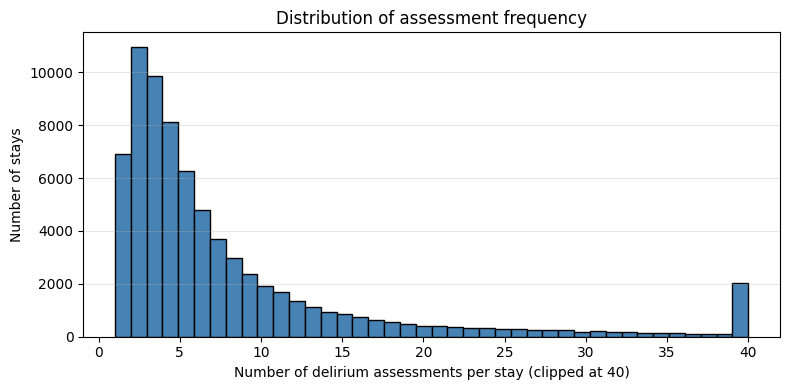

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    freq["n_assessments"].clip(upper=40), bins=40, color="steelblue", edgecolor="black"
)
ax.set_xlabel("Number of delirium assessments per stay (clipped at 40)")
ax.set_ylabel("Number of stays")
ax.set_title("Distribution of assessment frequency")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig("assessment_frequency")
plt.show()

## LOS filter impact on cohort

In [21]:
# How does a LOS threshold affect both delirious and non-delirious stays?
los_filter = con.execute("""
    SELECT 
        i.stay_id,
        EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 AS los_hours,
        CASE 
            WHEN d.ever_positive > 0 THEN 'ever_positive'
            WHEN d.ever_negative > 0 THEN 'only_negative'
            ELSE 'only_uta'
        END AS category
    FROM icu.icustays i
    JOIN (
        SELECT 
            stay_id,
            SUM(CASE WHEN value = 'Positive' THEN 1 ELSE 0 END) AS ever_positive,
            SUM(CASE WHEN value = 'Negative' THEN 1 ELSE 0 END) AS ever_negative
        FROM icu.chartevents
        WHERE itemid = 228332
        GROUP BY stay_id
    ) d ON i.stay_id = d.stay_id
""").df()

print("Coverage at different LOS thresholds:")
print(f"{'Threshold':<12}{'Ever-positive':<18}{'Only-negative':<18}{'Total':<10}")
for t in [12, 24, 48, 72]:
    kept = los_filter[los_filter["los_hours"] >= t]
    pos = (kept["category"] == "ever_positive").sum()
    neg = (kept["category"] == "only_negative").sum()
    total = len(kept)
    print(
        f">= {t:>3}h     {pos:>6,} ({pos/22462:>5.1%})   {neg:>6,} ({neg/47417:>5.1%})   {total:>6,}"
    )

Coverage at different LOS thresholds:
Threshold   Ever-positive     Only-negative     Total     
>=  12h     22,221 (98.9%)   45,797 (96.6%)   70,663
>=  24h     20,937 (93.2%)   36,464 (76.9%)   59,386
>=  48h     17,407 (77.5%)   19,040 (40.2%)   37,437
>=  72h     14,213 (63.3%)   10,560 (22.3%)   25,392


The 24h threshold retains the majority of delirium cases while ensuring enough temporal data for prediction and it doesn't bias the negative class as much as longer thresholds.

## Define the final cohort with justifications

In [22]:
# Cohort definition based on what we've explored:
# - Adults (MIMIC only has adults but we filter explicitly to be safe)
# - At least one CAM-ICU assessment (itemid 228332)
# - At least one assessment that yielded a usable label (Positive or Negative, not only UTA)
# - First positive (if any) occurred during the ICU stay, not before
# - ICU LOS of at least 24 hours

MIN_AGE = 18
MIN_LOS_HOURS = 24

con.execute(f"""
    CREATE OR REPLACE TABLE cohort AS
    WITH delirium_labels AS (
        -- Aggregate delirium assessments per stay
        SELECT 
            stay_id,
            SUM(CASE WHEN value = 'Positive' THEN 1 ELSE 0 END) AS n_positive,
            SUM(CASE WHEN value = 'Negative' THEN 1 ELSE 0 END) AS n_negative,
            MIN(CASE WHEN value = 'Positive' THEN charttime END) AS first_positive_time
        FROM icu.chartevents
        WHERE itemid = 228332
        GROUP BY stay_id
    )
    SELECT 
        i.stay_id,
        i.subject_id,
        i.hadm_id,
        i.first_careunit,
        i.intime,
        i.outtime,
        EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 AS los_hours,
        p.gender,
        p.anchor_age AS age,
        a.race,
        a.admission_type,
        d.n_positive,
        d.n_negative,
        d.first_positive_time,
        CASE WHEN d.n_positive > 0 THEN 1 ELSE 0 END AS ever_delirious
    FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    JOIN hosp.admissions a ON i.hadm_id = a.hadm_id
    JOIN delirium_labels d ON i.stay_id = d.stay_id
    WHERE p.anchor_age >= {MIN_AGE}
      AND (d.n_positive > 0 OR d.n_negative > 0)
      AND EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 >= {MIN_LOS_HOURS}
      AND (d.first_positive_time IS NULL OR d.first_positive_time >= i.intime)
""")

n_stays = con.execute("SELECT COUNT(*) FROM cohort").fetchone()[0]
n_patients = con.execute("SELECT COUNT(DISTINCT subject_id) FROM cohort").fetchone()[0]
n_delirious = con.execute("SELECT SUM(ever_delirious) FROM cohort").fetchone()[0]

print("Final cohort:")
print(f"  ICU stays: {n_stays:,}")
print(f"  Unique patients: {n_patients:,}")
print(f"  Ever delirious: {n_delirious:,} ({n_delirious/n_stays:.1%})")
print(
    f"  Never delirious: {n_stays - n_delirious:,} ({(n_stays - n_delirious)/n_stays:.1%})"
)

Final cohort:
  ICU stays: 57,054
  Unique patients: 42,329
  Ever delirious: 20,590 (36.1%)
  Never delirious: 36,464 (63.9%)


## Cohort attrition table

In [24]:
import pandas as pd

attrition = []

# Starting point
total_stays = con.execute("SELECT COUNT(*) FROM icu.icustays").fetchone()[0]
attrition.append(("All ICU stays in MIMIC-IV", total_stays, ""))

# After adult filter
adult_stays = con.execute("""
    SELECT COUNT(*) FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    WHERE p.anchor_age >= 18
""").fetchone()[0]
attrition.append(
    ("After adult filter (age >= 18)", adult_stays, f"-{total_stays - adult_stays:,}")
)

# After at-least-one-assessment filter
with_assessment = con.execute("""
    SELECT COUNT(*) FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    WHERE p.anchor_age >= 18
      AND i.stay_id IN (SELECT DISTINCT stay_id FROM icu.chartevents WHERE itemid = 228332)
""").fetchone()[0]
attrition.append(
    (
        "+ at least one CAM-ICU assessment",
        with_assessment,
        f"-{adult_stays - with_assessment:,}",
    )
)

# After UTA-only exclusion (require positive OR negative, not only UTA)
non_uta = con.execute("""
    SELECT COUNT(*) FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    JOIN (
        SELECT stay_id,
            SUM(CASE WHEN value IN ('Positive', 'Negative') THEN 1 ELSE 0 END) AS n_usable
        FROM icu.chartevents WHERE itemid = 228332
        GROUP BY stay_id
    ) d ON i.stay_id = d.stay_id
    WHERE p.anchor_age >= 18 AND d.n_usable > 0
""").fetchone()[0]
attrition.append(
    (
        "+ at least one assessment with usable label",
        non_uta,
        f"-{with_assessment - non_uta:,}",
    )
)

# After LOS >= 24h
los_filtered = con.execute("""
    SELECT COUNT(*) FROM icu.icustays i
    JOIN hosp.patients p ON i.subject_id = p.subject_id
    JOIN (
        SELECT stay_id,
            SUM(CASE WHEN value IN ('Positive', 'Negative') THEN 1 ELSE 0 END) AS n_usable
        FROM icu.chartevents WHERE itemid = 228332
        GROUP BY stay_id
    ) d ON i.stay_id = d.stay_id
    WHERE p.anchor_age >= 18 
      AND d.n_usable > 0
      AND EXTRACT(EPOCH FROM (i.outtime - i.intime)) / 3600 >= 24
""").fetchone()[0]
attrition.append(
    ("+ ICU LOS >= 24 hours", los_filtered, f"-{non_uta - los_filtered:,}")
)

# Final after pre-ICU positive exclusion
final = con.execute("SELECT COUNT(*) FROM cohort").fetchone()[0]
attrition.append(
    (
        "+ first positive not before ICU intime (final cohort)",
        final,
        f"-{los_filtered - final:,}",
    )
)

attrition_df = pd.DataFrame(
    attrition, columns=["Filter step", "Stays remaining", "Dropped"]
)
print(attrition_df.to_string(index=False))

                                          Filter step  Stays remaining Dropped
                            All ICU stays in MIMIC-IV            94458        
                       After adult filter (age >= 18)            94458      -0
                    + at least one CAM-ICU assessment            72944 -21,514
          + at least one assessment with usable label            69879  -3,065
                                + ICU LOS >= 24 hours            57401 -12,478
+ first positive not before ICU intime (final cohort)            57054    -347


## Cohort attrition plot

Saved ./figures/cohort_attrition.png


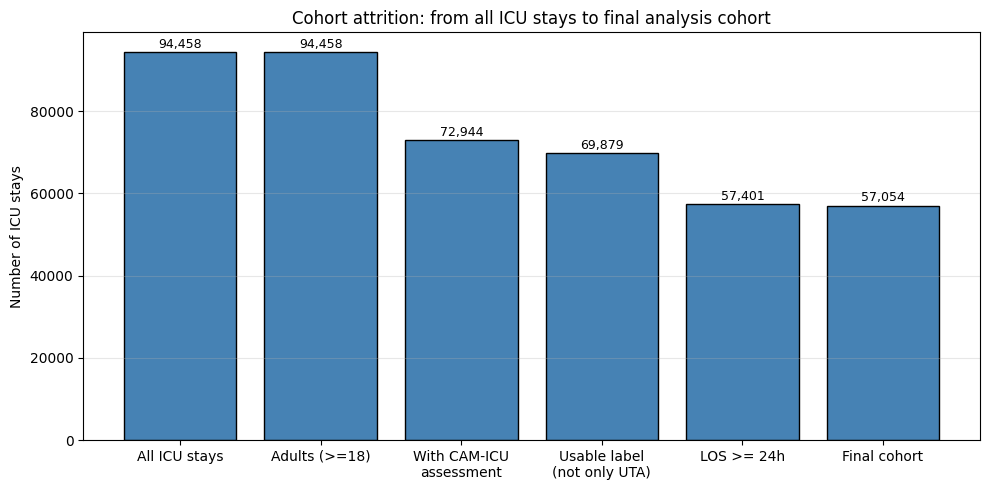

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

# Use shortened labels for the plot
labels = [
    "All ICU stays",
    "Adults (>=18)",
    "With CAM-ICU\nassessment",
    "Usable label\n(not only UTA)",
    "LOS >= 24h",
    "Final cohort",
]
values = [int(x) for x in attrition_df["Stays remaining"]]

bars = ax.bar(labels, values, color="steelblue", edgecolor="black")

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"{value:,}",
        ha="center",
        fontsize=9,
    )

ax.set_ylabel("Number of ICU stays")
ax.set_title("Cohort attrition: from all ICU stays to final analysis cohort")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_fig("cohort_attrition")
plt.show()

## Cohort demographics by delirium status

In [26]:
cohort_df = con.execute("SELECT * FROM cohort").df()
print(f"Cohort: {len(cohort_df):,} stays")

# Group by ever_delirious for comparison
summary = (
    cohort_df.groupby("ever_delirious")
    .agg(
        n_stays=("stay_id", "size"),
        n_patients=("subject_id", "nunique"),
        mean_age=("age", "mean"),
        median_age=("age", "median"),
        pct_female=("gender", lambda x: (x == "F").mean() * 100),
        median_los_h=("los_hours", "median"),
        mean_los_h=("los_hours", "mean"),
    )
    .round(1)
)
summary.index = ["Never delirious", "Ever delirious"]
print(summary.to_string())

Cohort: 57,054 stays
                 n_stays  n_patients  mean_age  median_age  pct_female  median_los_h  mean_los_h
Never delirious    36464       29545      62.4        64.0        43.3          49.4        67.6
Ever delirious     20590       16862      64.6        66.0        43.4         113.1       180.8


Delirious patients' stays are nearly 2.3x longer in ICU as is confirmed in the literature.

## Care unit distribution by delirium status

In [27]:
careunit_breakdown = (
    cohort_df.groupby(["first_careunit", "ever_delirious"]).size().unstack(fill_value=0)
)
careunit_breakdown.columns = ["never_delirious", "ever_delirious"]
careunit_breakdown["total"] = careunit_breakdown.sum(axis=1)
careunit_breakdown["delirium_rate"] = (
    careunit_breakdown["ever_delirious"] / careunit_breakdown["total"] * 100
).round(1)
careunit_breakdown = careunit_breakdown.sort_values("total", ascending=False)
print("Delirium rate by ICU type:")
print(careunit_breakdown.to_string())

Delirium rate by ICU type:
                                                  never_delirious  ever_delirious  total  delirium_rate
first_careunit                                                                                         
Medical Intensive Care Unit (MICU)                           5596            5820  11416           51.0
Cardiac Vascular Intensive Care Unit (CVICU)                 8129            2142  10271           20.9
Medical/Surgical Intensive Care Unit (MICU/SICU)             5526            3102   8628           36.0
Surgical Intensive Care Unit (SICU)                          4438            2756   7194           38.3
Coronary Care Unit (CCU)                                     4726            1747   6473           27.0
Trauma SICU (TSICU)                                          3523            2305   5828           39.6
Neuro Intermediate                                           3312            1375   4687           29.3
Neuro Surgical Intensive Care Unit (N

## Race distribution

In [28]:
race_breakdown = cohort_df["race"].value_counts().head(15)
print("Top 15 race categories in cohort:")
print(race_breakdown.to_string())

Top 15 race categories in cohort:
race
WHITE                             34367
UNKNOWN                            5952
BLACK/AFRICAN AMERICAN             5080
OTHER                              2171
WHITE - OTHER EUROPEAN             1690
UNABLE TO OBTAIN                    958
HISPANIC/LATINO - PUERTO RICAN      833
ASIAN - CHINESE                     675
WHITE - RUSSIAN                     641
ASIAN                               608
HISPANIC/LATINO - DOMINICAN         537
BLACK/CARIBBEAN ISLAND              410
BLACK/CAPE VERDEAN                  400
BLACK/AFRICAN                       300
PORTUGUESE                          292


Race needs consolidation. Multiple entries could be grouped into a single category. For example, "White", "White - British", "White - Other" could all be grouped as "White". This would simplify the analysis and ensure that we have enough samples in each category for meaningful comparisons.

## Race consolidation

In [29]:
def simplify_race(r):
    if pd.isna(r):
        return "UNKNOWN"
    r = str(r).upper()
    if "WHITE" in r or "PORTUGUESE" in r:
        return "WHITE"
    if "BLACK" in r or "AFRICAN" in r:
        return "BLACK"
    if "HISPANIC" in r or "LATINO" in r or "SOUTH AMERICAN" in r:
        return "HISPANIC"
    if "ASIAN" in r:
        return "ASIAN"
    if "UNKNOWN" in r or "UNABLE" in r or "DECLINED" in r:
        return "UNKNOWN"
    return "OTHER"


cohort_df["race_simple"] = cohort_df["race"].apply(simplify_race)

# Show the consolidation
print("Race after consolidation:")
print(cohort_df["race_simple"].value_counts().to_string())
print("\nAs percentages:")
print(
    (cohort_df["race_simple"].value_counts(normalize=True) * 100).round(1).to_string()
)

Race after consolidation:
race_simple
WHITE       37336
UNKNOWN      7165
BLACK        6190
OTHER        2423
HISPANIC     2183
ASIAN        1757

As percentages:
race_simple
WHITE       65.4
UNKNOWN     12.6
BLACK       10.8
OTHER        4.2
HISPANIC     3.8
ASIAN        3.1


## Save the cohort

In [33]:
cohort_df.to_parquet("./data/cohort.parquet", index=False, engine="pyarrow")
print(f"Saved cohort: {cohort_df.shape}")

Saved cohort: (57054, 16)
